# Video Game Commercial Success Prediction & Market Analysis

The goal of this project is to deliver a clear commercial narrative that game studios and publishers can use to minimize financial risk before greenlighting a new game's production.

When looking into creating new games studios and publishers investigate what has been historically successful. By analyzing characteristics of games that have already been released, we can help guide new game ideas to the right publishers to help propagate the game to a better sales pattern, allowing both the publisher and game developer to maximize their investment.

#### 1. Imports & Data Loading

In this section we collect our imports to be used to keep it clean and consise. We create an in-memory database to simulate what it would be like to be pulling data from a database in a production sense.

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# SQL alchemy
from sqlalchemy import create_engine, text

# scikitlearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.dummy import DummyClassifier

In [106]:
# create in-memory SQLite database
engine = create_engine('sqlite:///:memory:')

First we create an in-memory database using the `create_engine()` from SQLAlchemy.

In [107]:
# load raw data
df_raw = pd.read_csv('datasets/Video_Games_Sales.csv')

We then load our dataset into a Pandas DataFrame to be loaded into our database.

In [108]:
# ingest raw data into database
df_raw.to_sql('raw_game_sales', con=engine, index=False, if_exists='replace')

16719

In [109]:
# run query against database to confirm ingestion
query = """
SELECT count(*)
FROM raw_game_sales
"""

In [110]:
with engine.connect() as conn:
    results = conn.execute(text(query))
    print(f'Successfully ingested {results.scalar():,} records into in-memory table "raw_game_sales".')

Successfully ingested 16,719 records into in-memory table "raw_game_sales".


After ingesting our dataset into the database we check that it was succefully ingested. We run a sample query that checks the count of the table we then print the results showing that the data was successfully ingested into the table.

In [111]:
# pull data from database to pandas DataFrame
query = """
SELECT platform as platform,
    year_of_release as release_year,
    genre as genre,
    publisher as publisher,
    global_sales as global_sales
FROM raw_game_sales
WHERE global_sales IS NOT NULL
AND genre IS NOT NULL
AND year_of_release IS NOT NULL
AND publisher IS NOT NULL;
"""

This is the query we will use to pull the data from the database. We transform the column names to a standardized format.
|Original|Converted|
|:----:|:----:|
|Year_of_Release|release_year|
|Genre|genre|
|Publisher|publisher|
|Global_Sales|global_sales|

We pull the records removing the null rows (using `WHERE ____ IS NOT NULL`) in this process we eliminate the need to remove `Null` values in the cleaning step.

In [112]:
with engine.connect() as conn:
    results = conn.execute(text(query))
    df_clean = pd.DataFrame(results)

In [113]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16416 entries, 0 to 16415
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   platform      16416 non-null  object 
 1   release_year  16416 non-null  float64
 2   genre         16416 non-null  object 
 3   publisher     16416 non-null  object 
 4   global_sales  16416 non-null  float64
dtypes: float64(2), object(3)
memory usage: 641.4+ KB


#### 2. Data Cleaning & Target Creation

In [114]:
# parse release_year to 'int' from 'float64'
df_clean['release_year'] = df_clean['release_year'].astype(int)

Looking over the data info we see that the `release_year` is of the type `float` (e.g., `2013.0`) We use the Pandas function `.astype()` to parse this data into an `int` type.

In [115]:
# confirm that the release_year column has been converted to 'int'
df_clean['release_year'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 16416 entries, 0 to 16415
Series name: release_year
Non-Null Count  Dtype
--------------  -----
16416 non-null  int64
dtypes: int64(1)
memory usage: 128.4 KB


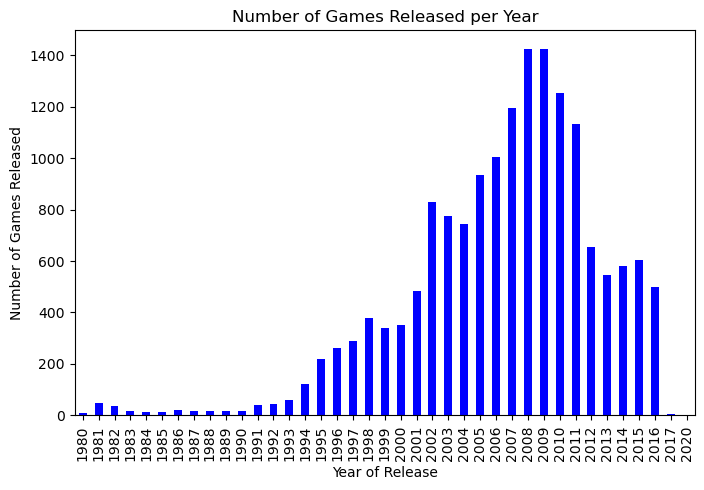

In [116]:
# chart showing the number of games released per year
plt.figure(figsize=(8,5))
df_clean['release_year'].value_counts().sort_index().plot(kind='bar', color='Blue', title='Number of Games Released per Year')
plt.xlabel('Year of Release')
plt.ylabel('Number of Games Released')

plt.show()


The chart shows that the bulk of the games in the data was released between **1994** to **2016**. 

##### Create Dynamic Target

In [117]:
# top 20% global sales within each release year
df_clean['year_80th_p'] = df_clean.groupby('release_year')['global_sales'].transform(lambda x: x.quantile(0.80))
df_clean['is_hit'] = (df_clean['global_sales'] >= df_clean['year_80th_p']).astype(int)

Given that we are basing our data on the `global_sales` column we create a dynamic target of the games in the top 20th percentile as the games in this split can be considered `hits`.

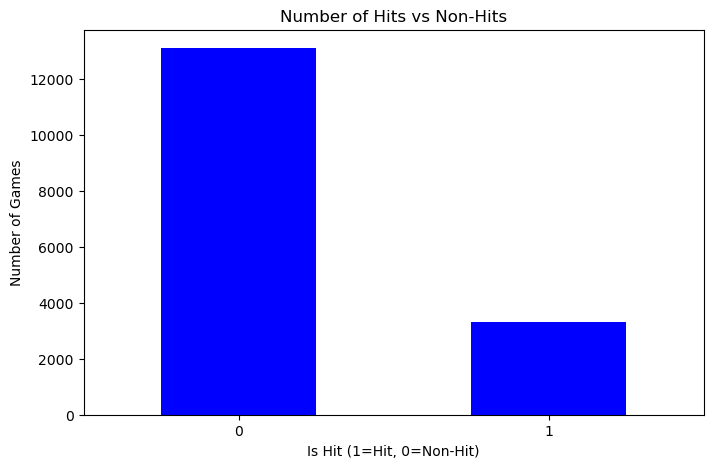

In [118]:
# chart showing the number of hits vs non-hits
plt.figure(figsize=(8,5))
df_clean['is_hit'].value_counts().plot(kind='bar', color='Blue', title='Number of Hits vs Non-Hits')

plt.xlabel('Is Hit (1=Hit, 0=Non-Hit)')
plt.ylabel('Number of Games')
plt.xticks(rotation=0)

plt.show()

The chart shows the distribution of games classified as **hits** versus **non-hits**.

- **1 (Hit):** Games whose global sales are at or above the 80th percentile for their release year.
- **0 (Non-Hit):** Games below that yearly threshold.
- The chart demonstrates that hits represent approximately **20%** of the dataset, while non-hits represent approximately **80%**.
- This class imbalance is expected because the target specifically identifies only the top-performing games.

In [119]:
df_clean['publisher'].value_counts()

publisher
Electronic Arts                 1344
Activision                       976
Namco Bandai Games               935
Ubisoft                          930
Konami Digital Entertainment     825
                                ... 
Max Five                           1
On Demand                          1
Bomb                               1
Detn8 Games                        1
Red Flagship                       1
Name: count, Length: 579, dtype: int64

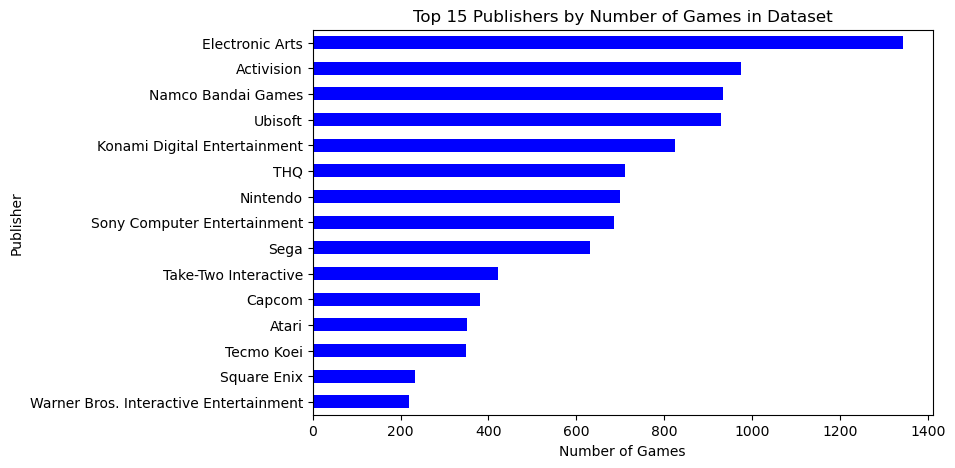

In [125]:
# chart showing the publisher disparity in the dataset
plt.figure(figsize=(8,5))
df_clean['publisher'].value_counts().nlargest(15).sort_values(ascending=True).plot(kind='barh', color='Blue', title='Top 15 Publishers by Number of Games in Dataset')

plt.xlabel('Number of Games')
plt.ylabel('Publisher')
plt.show()


The chart shows the top 15 publishers by the number of games they have in the dataset.

In [ ]:
# reduction of publisher cardinality
top_publishers = df_clean['publisher'].value_counts().nlargest(15).index
df_clean['publisher_grouped'] = df_clean['publisher'].apply(lambda x: x if x in top_publishers else 'Other')

By grouping publishers with many games while all other publishers are grouped into an `othter` category. It reduces the number of publisher values in the dataset helping to prevent model overfitting to publishers with very few observations.

Grouping the publishers into `publisher_grouped` feature preserves information about the most frequently represented publishers and simplifies the dataset for analysis and modeling.

The grouping is based on dataset frquency and does not imply that the publishers in the `other` column are part of the same business family.

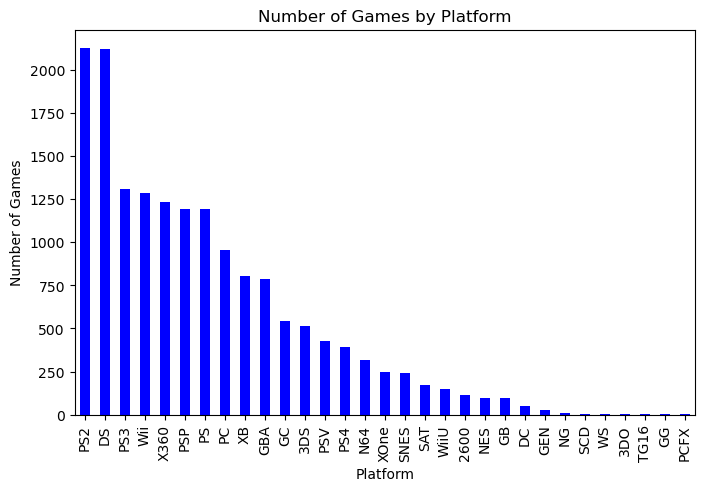

In [130]:
plt.figure(figsize=(8,5))
df_clean['platform'].value_counts().plot(kind='bar', color='Blue', title='Number of Games by Platform')
plt.xlabel('Platform')
plt.ylabel('Number of Games')
plt.show()

The chart shows the platform based on the amount of games made for them.

In looking at the chart we see a lot of systems that belong to the same platform family.

|XBox |Playstation |Nintendo|
|:---:|   :---:    |  :---: |
|XB   |PS          |NES     |
|X360 |PS2         |SNES    |
|XOne |PS3         |N64     |
|     |PS4         |GC      |
|     |PSP         |Wii     |
|     |PSV         |WiiU    |
|     |            |GB      |
|     |            |GBA     |
|     |            |DS      |
|     |            |3DS     |


In [131]:
# get top platforms
nin = 'nintendo'
pl = 'playstation'
xb = 'xbox'
platform_map = {
    'PS': pl, 'PS2': pl, 'PS3': pl, 'PS4': pl, 'PSP': pl, 'PSV': pl,
    'XB': xb, 'X360': xb, 'XOne': xb,
    'Wii': nin, 'WiiU': nin, 'DS': nin, '3DS': nin, 'GBA': nin, 'GB': nin, 'GC': nin, 'N64': nin, 'NES': nin, 'SNES': nin
}

df_clean['platform_family'] = df_clean['platform'].map(platform_map).fillna('Other')

The above code consolidates these platforms into specific platform families (`Nintendo`, `Playstation`, and `Xbox`). This helps to reduce the cardinality and standardizes the dataset. 

By grouping them into `platform_family` we get a true representaion of platforms and simplifies the dataset allowing the model to gain a true representaion of platforms.

The chart below shows the platform distribution after the grouping.

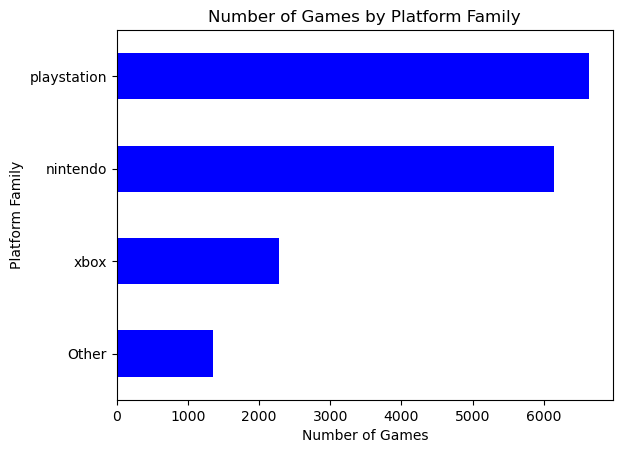

In [134]:
df_clean['platform_family'].value_counts().sort_values(ascending=True).plot(kind='barh', color='Blue', title='Number of Games by Platform Family')
plt.xlabel('Number of Games')
plt.ylabel('Platform Family')
plt.show()

#### 3. Feature Selection & Train/Test Split

In [ ]:
# Strictly pre-release features to prevent target leakage
features = ['platform_family', 'genre', 'publisher_grouped', 'release_year']

In [ ]:
# temporal time split
cutoff_year = 2013

train_mask = df_clean['release_year'] < cutoff_year
test_mask = df_clean['release_year'] >= cutoff_year

X = df_clean[features]
y = df_clean['is_hit']

X_train = df_clean.loc[train_mask, features]
y_train = df_clean.loc[train_mask, 'is_hit']

X_test = df_clean.loc[test_mask, features]
y_test = df_clean.loc[test_mask, 'is_hit']


#### 4. Preprocessing & Model Training, Baseline Comparison & Probability Evaluation

In [ ]:
categorical_features = ['platform_family', 'genre', 'publisher_grouped']
numeric_features = ['release_year']

In [ ]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), categorical_features)
    ]
)

In [ ]:
models = {
    'Dummy Classifier': DummyClassifier(strategy='stratified', random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'HistGradient Boosting': HistGradientBoostingClassifier(random_state=42, class_weight='balanced'),
}

In [ ]:
fitted_pipelines = {}

In [ ]:
print('--- 5-Fold Cross-Validation (ROC-AUC) ---')

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # fit on training data and store pipeline
    pipeline.fit(X_train, y_train)
    fitted_pipelines[name] = pipeline

    cv_score = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='roc_auc')

    print(f'{name} -> Mean ROC-AUC: {cv_score.mean():.4f} (+- {cv_score.std():.4f})')

### 5. Test Set Evaluation & Metrics (Precision, Recall, F1, ROC-AUC)

In [ ]:
for name, pipeline in fitted_pipelines.items():
    if name == 'Dummy Classifier':
        continue

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    auc_score = roc_auc_score(y_test, y_proba)

    print(f'--- Model: {name} ---')
    print(f'Test ROC-AUC Score: {auc_score:.4f} (Target: >= 0.75)')
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred))

### 6. Interpretability: Logistic Regression Odds Ratios

In [ ]:
# Logistic Regression Model
log_reg_model = fitted_pipelines['LogisticRegression'].named_steps['classifier']

# onehotencoder feature names
ohe_feature_names = fitted_pipelines['LogisticRegression'].named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)

all_feature_names = numeric_features + list(ohe_feature_names)

odd_ratios = pd.DataFrame({
    'feature': all_feature_names,
    'coef': log_reg_model.coef_[0],
    'odds_ratio': np.exp(log_reg_model.coef_[0])
    }).sort_values(by='odds_ratio', ascending=False)

print('--- Top 10 Positive Drivers of Commercial Hits (Odds Ratios) ---')
print(odd_ratios.head(10).to_string(index=False))


### Visualizations: Heatmap & Confusion Matrix

In [ ]:

X_train_encoded = fitted_pipelines['LogisticRegression'].named_steps['preprocessor'].transform(X_train)
df_encoded = pd.DataFrame(X_train_encoded, columns=all_feature_names)
df_encoded['is_hit'] = y_train.values

top_corr_features = df_encoded.corr()['is_hit'].abs().nlargest(10).index

plt.figure(figsize=(8, 5))

corr_map = sns.heatmap(df_encoded[top_corr_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
corr_map.set_title('Correlation Heatmap (Top Predictors vs. Is Hit)')

plt.show()

In [ ]:
# Confusion Matrix

best_model = fitted_pipelines['HistGradient Boosting']
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 5))

hgb_matrix = sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Hit', 'Is Hit'],
    yticklabels=['Non-Hit', 'Is Hit'],
)

hgb_matrix.set_title('confusion Matrix: HistGradient Boosting (Test Set)')
hgb_matrix.set_xlabel('Predicted Label')
hgb_matrix.set_ylabel('True Label')

plt.show()

In [ ]:
# adjusted threshold to fine tune false positives/negatives
y_proba = fitted_pipelines['HistGradient Boosting'].predict_proba(X_test)[:, 1]

custom_threshold = 0.65
y_pred_tuned = (y_proba >= custom_threshold).astype(int)

print(f'--- Performance at Threshold = {custom_threshold} ---')
print(classification_report(y_test, y_pred_tuned))


In [ ]:
print('confusion_matrix:')
cm = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(8, 5))

hgb_matrix = sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Hit', 'Is Hit'],
    yticklabels=['Non-Hit', 'Is Hit'],
)

hgb_matrix.set_title('confusion Matrix: HistGradient Boosting (Test Set)')
hgb_matrix.set_xlabel('Predicted Label')
hgb_matrix.set_ylabel('True Label')

plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve, roc_curve

# 1. Extract predicted probabilities for the positive class (Hit)
y_proba = fitted_pipelines['HistGradient Boosting'].predict_proba(X_test)[:, 1]

# 2. Find optimal threshold based on Maximum F1-Score
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

best_f1_idx = np.argmax(f1_scores)
best_f1_threshold = thresholds[best_f1_idx]
best_f1_score = f1_scores[best_f1_idx]

# 3. Find optimal threshold based on Youden's J Statistic (ROC Curve)
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
j_scores = tpr - fpr

best_j_idx = np.argmax(j_scores)
best_j_threshold = roc_thresholds[best_j_idx]

print("="*50)
print("AUTOMATED THRESHOLD OPTIMIZATION RESULTS")
print("="*50)
print(f"Optimal Threshold for Max F1-Score: {best_f1_threshold:.4f}")
print(f"  -> Highest Achievable F1-Score: {best_f1_score:.4f}")
print(f"  -> Associated Precision:         {precisions[best_f1_idx]:.4f}")
print(f"  -> Associated Recall:            {recalls[best_f1_idx]:.4f}")
print("-" * 50)
print(f"Optimal Threshold for Youden's J:  {best_j_threshold:.4f}")

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='blue', lw=2)
plt.plot(thresholds, recalls[:-1], label='Recall', color='green', lw=2)
plt.plot(thresholds, f1_scores[:-1], label='F1-Score', color='purple', linestyle='--', lw=2)

plt.axvline(x=best_f1_threshold, color='red', linestyle=':', label=f'Max F1 Threshold ({best_f1_threshold:.2f})')

plt.title('Precision, Recall, and F1-Score vs. Decision Threshold')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()